### DEM Derivatives
Calcul de toutes les couches terrain dérivées depuis le DEM local (`data/mono_dem.tif`).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))  # rend durpy et derivedDem importables
#sys.path.insert(0, r"D:\REPOSITORY\FloodRM")

import matplotlib.pyplot as plt
import numpy as np

from durpy.derivedDem import (
    init_local_engine,
    derive_slope,
    derive_aspect,
    derive_curvature,
    derive_twi,
    derive_flow_accumulation,
)

DEM_PATH = "data/mono_dem.tif"
init_local_engine(DEM_PATH)

DEM chargé : (11010, 4500) | ext=[0.687639184, 1.937639284, 6.279305658, 9.337639236]


In [2]:
slope,  ext = derive_slope()
aspect, ext = derive_aspect()
curv,   ext = derive_curvature()
twi,    ext = derive_twi()
facc,   ext = derive_flow_accumulation()

🗺️  raster enregistré : .\_tmp_dem_pysheds.tif


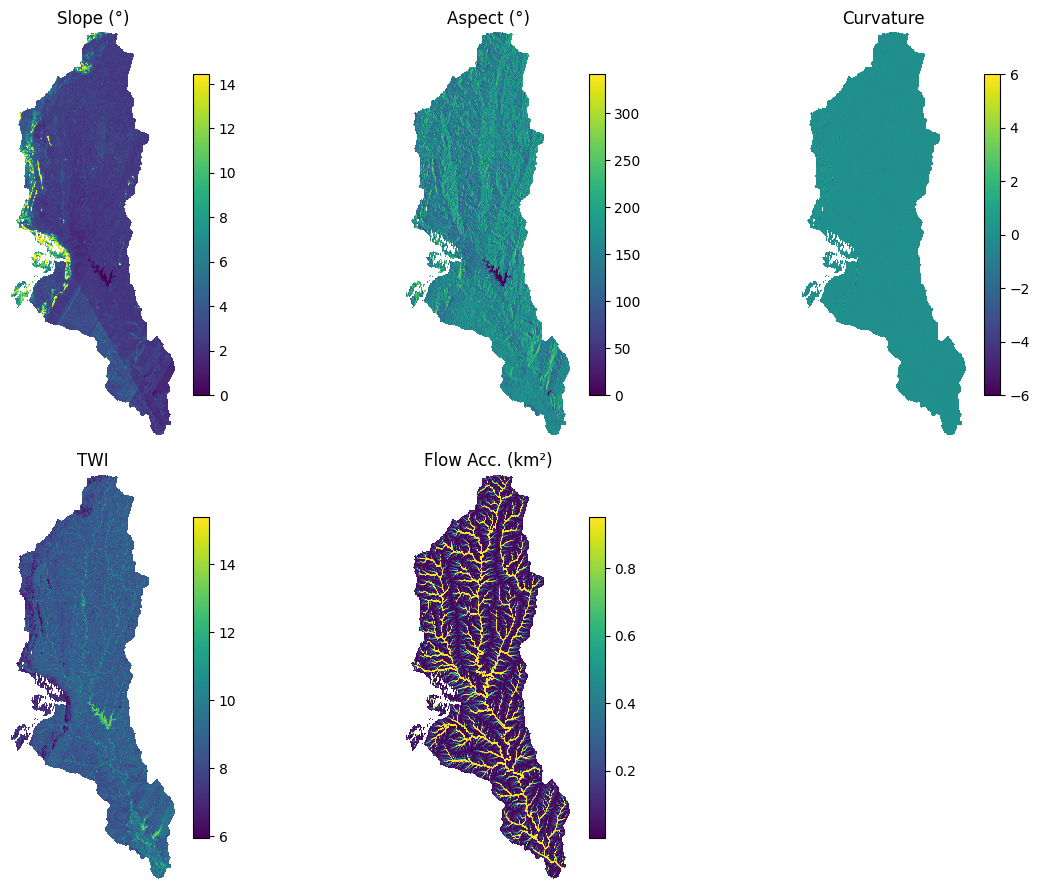

In [3]:
layers = {
    "Slope (°)":       slope,
    "Aspect (°)":      aspect,
    "Curvature":       curv,
    "TWI":             twi,
    "Flow Acc. (km²)": facc,
}

fig, axes = plt.subplots(2, 3, figsize=(12, 9))
for ax, (title, arr) in zip(axes.flat, layers.items()):
    im = ax.imshow(
        arr, cmap="viridis",
        vmin=np.nanpercentile(arr, 2),
        vmax=np.nanpercentile(arr, 98),
    )
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax, fraction=0.046)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Accès direct aux tableaux numpy après calcul
from durpy.variables import LAYERS

print("Couches disponibles dans LAYERS :", list(LAYERS.keys()))
print("Shape slope  :", LAYERS["slope"].shape)
print("Shape twi    :", LAYERS["twi"].shape)